# Perform differential gene accessibility analysis between treatment-induced epigenetic classes and the untreated epigenetic class

## Import R functions

In [40]:
suppressPackageStartupMessages({
    library(ArchR)
    library(dplyr)
    library(readr)
    library(ggrepel)
    library(ggplot2)
    library(eulerr)
})

Warning message:
“package ‘eulerr’ was built under R version 4.3.3”


## Import and further format ArchR project 

In [29]:
# Fix random number generator to that used locally 
RNGkind("L'Ecuyer-CMRG")

# Set thread count
addArchRThreads(threads = 1)

# load ArchR project
proj_fil <- loadArchRProject("../../Data/ArchR_Projects/Save_SW620_DATAC_Results")

#Copy number clones are defined using the CNA-consistent cell ids. 
# For ease of analysis, we now add CNA-consistent cell ids to the ArchR project.

# ATAC-consistent cell ids
proj_fil_ids <- proj_fil$cellNames
proj_fil_ids_mod <- proj_fil_ids 

# First, replace dsiv barcodes with the corresponding cell id
dsiv_barcodes <- read_csv("../../Data/Other/SW620bc_DSIV_barcode_matching.csv",
                          col_types = "cc") 

for (id in proj_fil_ids_mod){
  if (id %in% dsiv_barcodes$cell_barcode){
    proj_fil_ids[proj_fil_ids == id] = dsiv_barcodes[dsiv_barcodes$cell_barcode == id,]$sample_name
  }
}

# Second, remove extra labelling and cell barcodes for other samples
proj_fil_ids <- str_replace(proj_fil_ids,
                            "SW620bc_DSIb_DATAC#|SW620bc_POTa_DATAC#|SW620bc_DSIa_DATAC#|SW620bc_POTb_DATAC#|SW620bc_DT1_P1a_DATAC#|SW620bc_DT1_P1b_DATAC#","")
proj_fil_ids <- str_replace(proj_fil_ids,
                            "_ATAATGTG|_TACTCATA|_TCGATATC","")

# Add CNA-consistent cell ids 
proj_fil$cellNames_CNV <- proj_fil_ids


# Import genetic clades and epigenetic classes
clades <- read_csv("../../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv")
rownames(clades) <- clades$Cell_id

proj_fil$GeneticClade <- as.character(clades[proj_fil$cellNames_CNV,]$SuperClade)
proj_fil$GeneticClade_Full <- as.character(clades[proj_fil$cellNames_CNV,]$Clade)

epi_classes <- read_csv("../../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv")
rownames(epi_classes) <- epi_classes$Cell_id

proj_fil$EpigeneticClass <- epi_classes[proj_fil$cellNames_CNV,]$consensus_cluster

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

In [30]:
# LSI dimensionality reduction
proj_fil <- addIterativeLSI(
  ArchRProj = proj_fil,
  useMatrix = "TileMatrix", 
  name = "IterativeLSI", 
  iterations = 4, 
  clusterParams = list( #See Seurat::FindClusters
    resolution = c(0.1,0.5,1,2), 
    sampleCells = 10000, 
    n.start = 10
  ), 
  varFeatures = 25000, 
  dimsToUse = 1:30,
  force = TRUE
)

# Clustering using Seurat
proj_fil  <- addClusters(
  input = proj_fil,
  reducedDims = "IterativeLSI",
  method = "Seurat",
  name = "Clusters",
  resolution =0.5,
  dimsToUse = c(1:30), 
  scaleDims=NULL,
  force = TRUE
)

proj_fil <- addUMAP(
  ArchRProj = proj_fil, 
  reducedDims = "IterativeLSI", 
  name = "UMAP", 
  nNeighbors = 30, 
  minDist = 0.5, 
  metric = "cosine",
  force = TRUE
)


Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-5a7710015aa6-Date-2026-02-23_Time-14-41-12.433191.log
If there is an issue, please report to github with logFile!

2026-02-23 14:41:14.541689 : Computing Total Across All Features, 0.004 mins elapsed.

2026-02-23 14:41:15.503754 : Computing Top Features, 0.02 mins elapsed.

###########
2026-02-23 14:41:16.199541 : Running LSI (1 of 4) on Top Features, 0.031 mins elapsed.
###########

2026-02-23 14:41:16.208122 : Creating Partial Matrix, 0.031 mins elapsed.

2026-02-23 14:41:19.145089 : Computing LSI, 0.08 mins elapsed.

2026-02-23 14:41:26.348168 : Identifying Clusters, 0.2 mins elapsed.

2026-02-23 14:41:28.046394 : Identified 1 Clusters, 0.229 mins elapsed.

2026-02-23 14:41:28.071701 : Saving LSI Iteration, 0.229 mins elapsed.



2026-02-23 14:41:32.013772 : Identified 1 Cluster, Continuing with Previous Features!, 0.295 mins elapsed.

###########
2026-02-23 14:41:32.016065 : Running LSI (2 of 4) on Variable Feat

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 668
Number of edges: 49370

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8133
Number of communities: 3
Elapsed time: 0 seconds


2026-02-23 14:42:48.717571 : Testing Outlier Clusters, 0.019 mins elapsed.

2026-02-23 14:42:48.721214 : Assigning Cluster Names to 3 Clusters, 0.019 mins elapsed.

2026-02-23 14:42:48.748724 : Finished addClusters, 0.019 mins elapsed.

14:42:48 UMAP embedding parameters a = 0.583 b = 1.334

14:42:48 Read 668 rows and found 30 numeric columns

14:42:48 Using Annoy for neighbor search, n_neighbors = 30

14:42:48 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:42:48 Writing NN index file to temp file /var/folders/f3/1rtmfwtj5bg3c32s2xf8fpdn1m18m5/T//RtmpGbWoXt/file5a7752e35347

14:42:48 Searching Annoy index using 4 threads, search_k = 3000

14:42:48 Annoy recall = 100%

14:42:49 Commencing smooth kNN distance calibration using 4 threads
 with target n_neighbors = 30


In [74]:
saveArchRProject(ArchRProj = proj_fil, outputDirectory = "../../Data/ArchR_Projects/Save_SW620_DATAC_Results", load = FALSE)

Saving ArchRProject...



## Differential gene accessibility analysis: alpha vs beta

In [31]:
proj_fil <- addImputeWeights(proj_fil)

pathways <- readRDS("../../Data/ATAC_Data/GeneExpressionScores/HallmarkPathways.rds")

markerTest <- getMarkerFeatures(
  ArchRProj = proj_fil, 
  useMatrix = "GeneScoreMatrix",
  groupBy = "EpigeneticClass",
  testMethod = "wilcoxon",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  useGroups = "β",
  bgdGroups = "α"
)

markerList <- data.frame(getMarkers( markerTest , cutOff = "FDR <= 1 & (Log2FC >= 0 | Log2FC <= 0)")[["β"]])

genes <- c()
for (p in names(pathways)){
  genes <- rbind(genes, cbind("name" = pathways[[p]][which(pathways[[p]] %in% markerList$name)],
                              "Pathway" = rep(p, length(pathways[[p]][which(pathways[[p]] %in% markerList$name)]))))
}

genes <- data.frame(genes)

markerList <- merge(markerList, genes, by = "name", all.x = TRUE)
colnames(markerList)[10] <- "Pathway"

markerList$Pathway <- ifelse(is.na( markerList$Pathway), "Other",  markerList$Pathway)

markerList <- markerList %>% mutate(signif = case_when( FDR < 0.01 &
                                                          Log2FC <= log2(0.75) ~ "1",
                                                        FDR < 0.01 &
                                                          Log2FC >= log2(4/3) ~ "2",
                                                        .default = "0"))
## Differential gene accessibility analysis: alpha vs beta
label_genes <- markerList %>% filter( signif %in% c("1","2")  & Pathway != "Other" & ((-log10(FDR) > 2.5 & Log2FC < 0)| 
                                                                                        ( -log10(FDR) > 5.5 & Log2FC > 0) |
                                                                                        Log2FC > 1.25 |
                                                                                        Log2FC < -0.75) ) %>%
  distinct(name, .keep_all = T)

write_csv(label_genes[,c("name","Pathway")], "../../Data/ATAC_Data/DifferentialGeneAccessibility/VolcanoPlot_AlphavBeta_TopGenes_PathwayInfo.csv")
write_csv(markerList, "../../Data/ATAC_Data/DifferentialGeneAccessibility/VolcanoPlot_AlphavBeta_AllGenes_PathwayInfo.csv")


ArchR logging to : ArchRLogs/ArchR-addImputeWeights-5a7710b80127-Date-2026-02-23_Time-14-43-19.677141.log
If there is an issue, please report to github with logFile!

2026-02-23 14:43:20.205353 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-5a772053b004-Date-2026-02-23_Time-14-43-20.731107.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-02-23 14:43:21.510169 : Matching Known Biases, 0.003 mins elapsed.

2026-02-23 14:43:22.432065 : Computing Pairwise Tests (1 of 1), 0.018 mins elapsed.

Pairwise Test β : Seqnames chr1

Pairwise Test β : Seqnames chr10

Pairwise Test β : Seqnames chr11

Pairwise Test β : Seqnames chr12

Pairwise Test β : Seqnames chr13

Pairwise Test β : Seqnames chr14

Pairwise Test β : Seqnames chr15

Pairwise Test β : Seqnames chr16

Pairwise Test β : Seqnames chr17

Pairwise Test β : Seqnames chr18

Pairwise Test β : Seqnames chr19

Pa

### Volcano plot

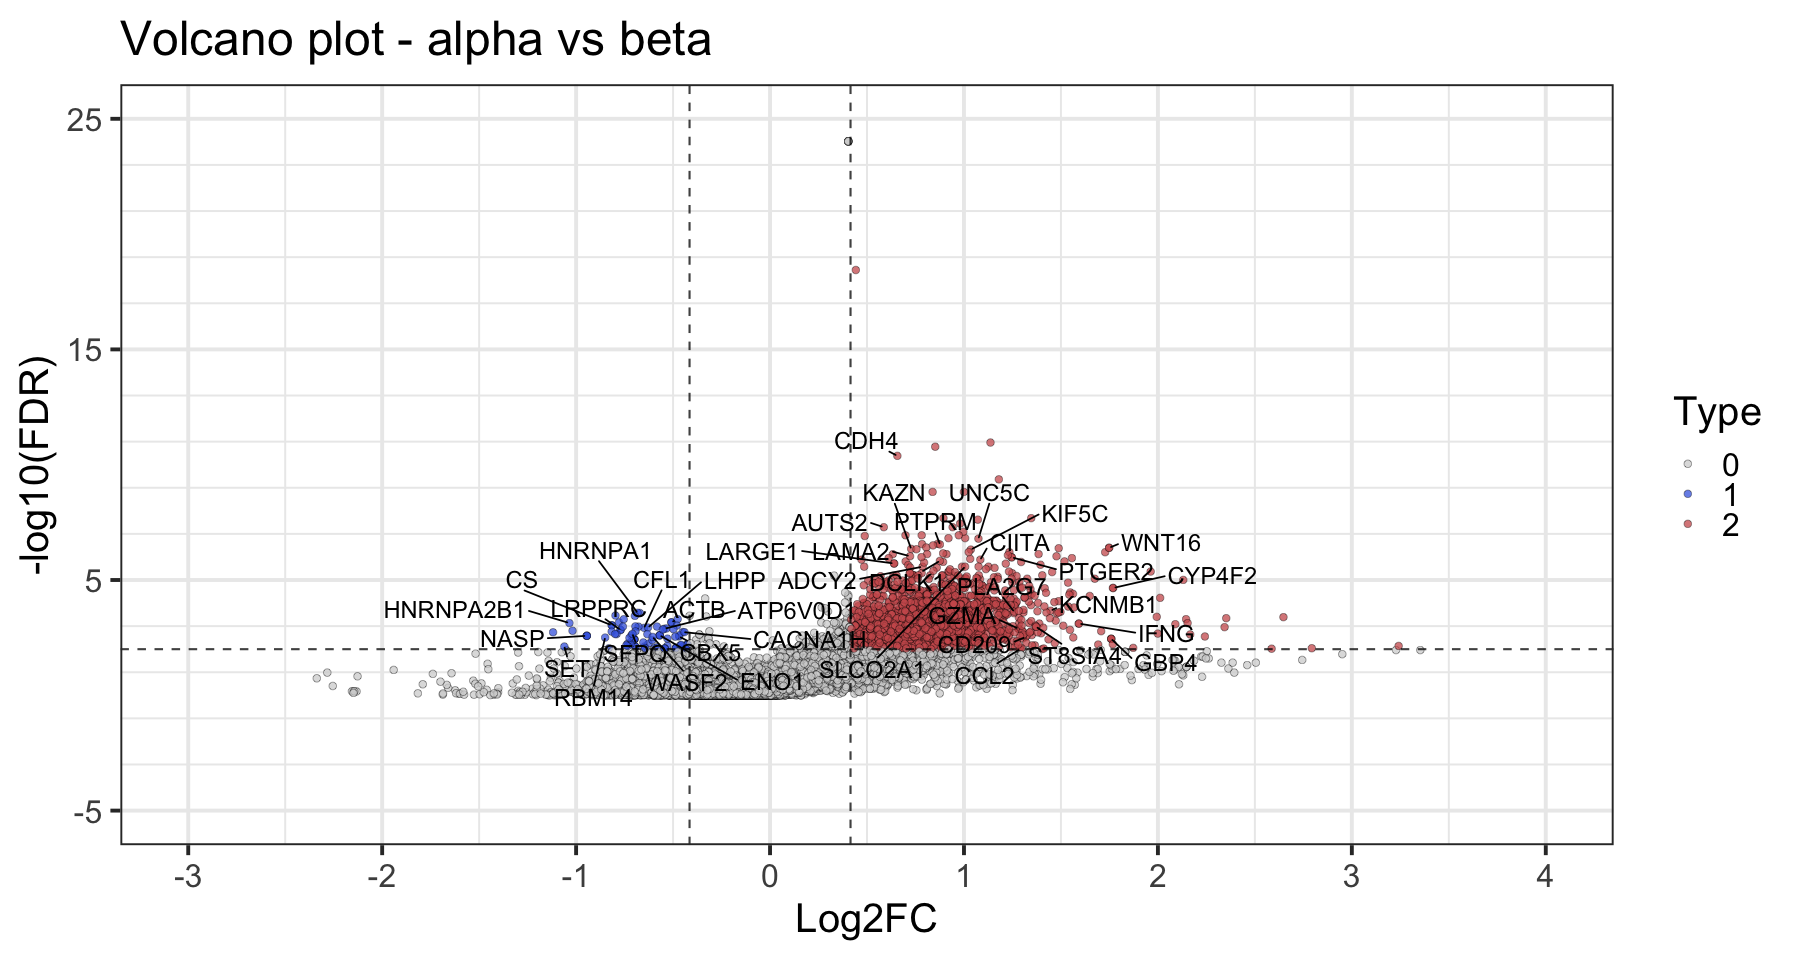

In [37]:
options(repr.plot.width=15, repr.plot.height=8)
p <- ggplot(markerList, aes(x = Log2FC, y = -log10(FDR))) +
  geom_point(aes(fill = signif), shape = 21,color = "black" , size = 2, stroke = 0.2,, alpha = 0.75)+
  scale_fill_manual(name = "Type",
                    values = c("0" = "lightgrey",
                               "1" = "royalblue",
                               "2" = "indianred"))+
  geom_vline(aes(xintercept = log2(4/3)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  geom_vline(aes(xintercept = log2(0.75)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  geom_hline(aes(yintercept = -log10(0.01)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  scale_x_continuous(breaks = seq(-3,4,1), minor_breaks = seq(-3,4,0.5))+
  scale_y_continuous(breaks = seq(-5,40,10), minor_breaks = seq(-5,40,2))+
  coord_cartesian(xlim = c(-3,4), ylim = c(-5,25))+
  theme_bw(base_size = 24) +
  geom_text_repel(
    data = label_genes,
    aes(label = name),
    colour = "black",
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0
  ) +
  labs(title = "Volcano plot - alpha vs beta")
p

### Venn diagram

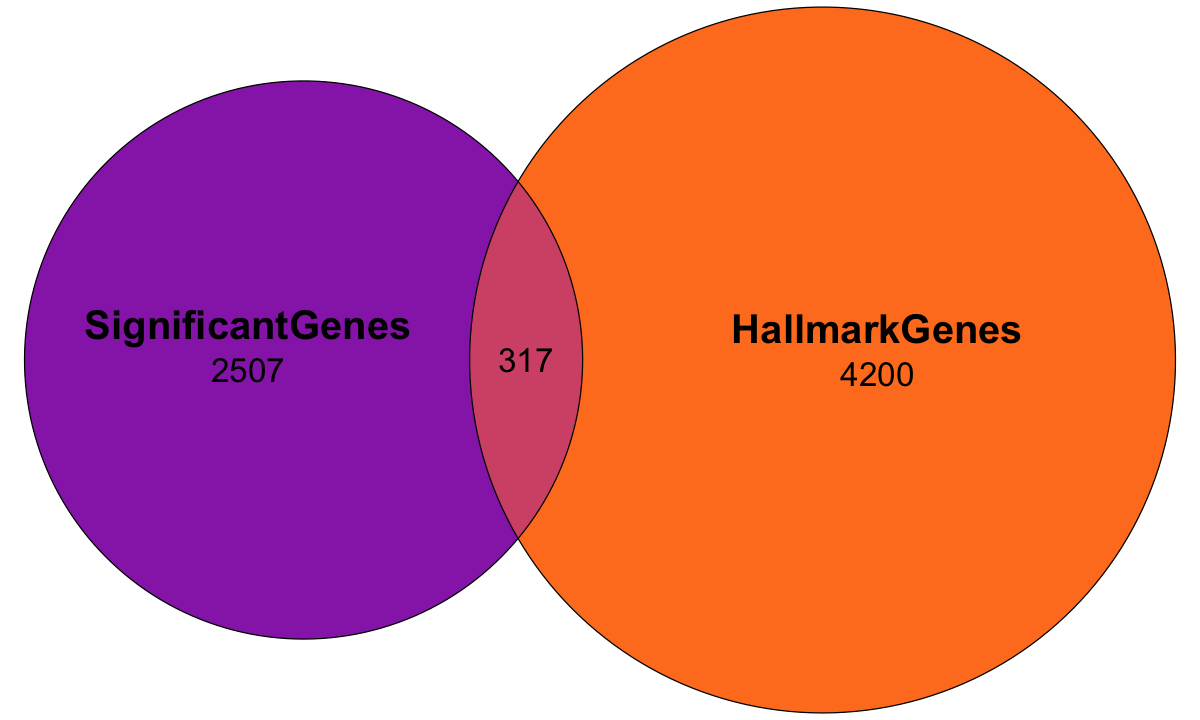

In [43]:
e <- euler(c("SignificantGenes" = length(unique(markerList[markerList$signif != 0,]$name)),
             "HallmarkGenes" = 4200,
             "SignificantGenes&HallmarkGenes" = length(unique(markerList[markerList$signif != 0 & markerList$Pathway != "Other",]$name))))

options(repr.plot.width=10, repr.plot.height=6)

plot(e, fills = c("#9731b6ff","#ff7f25ff"), fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

### Barplot of proportion of genes per pathway that are differentially accessible

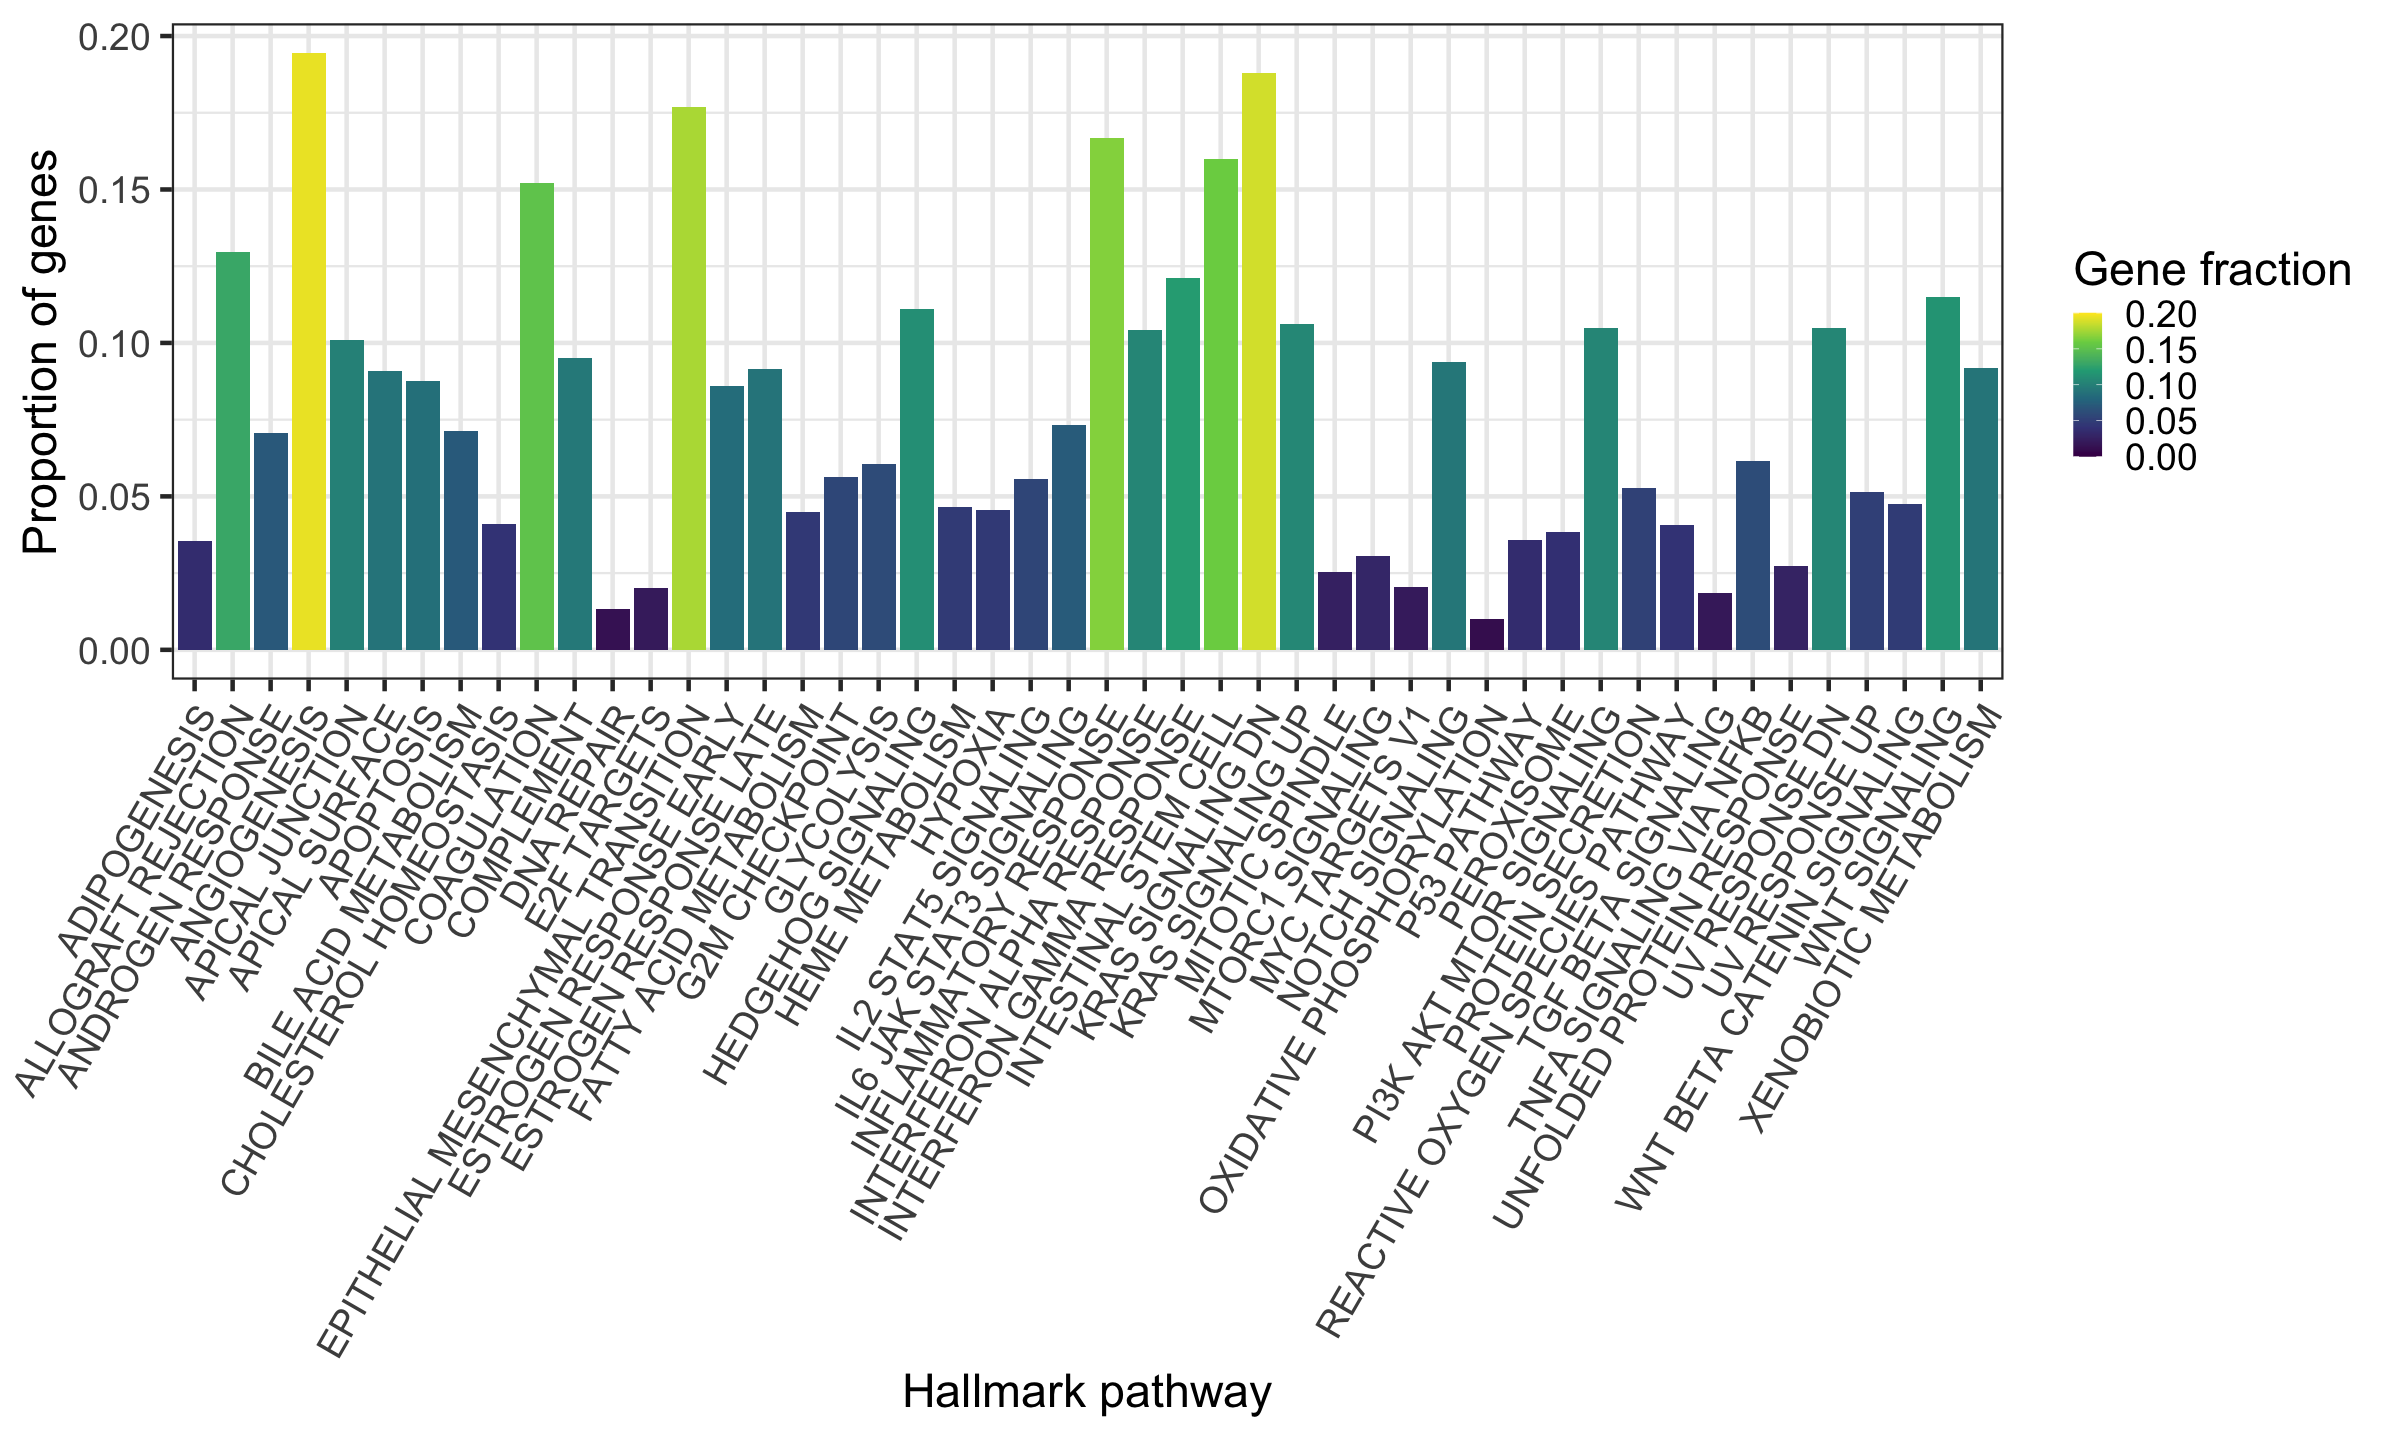

In [59]:
markerList$Pathway <- gsub("HALLMARK_","",markerList$Pathway)
markerList$Pathway <- gsub("_", " ", markerList$Pathway)

sig_counts <- markerList %>%
  filter(Pathway != "Other", signif != 0) %>%
  count(Pathway, name = "n_sig")

names <- gsub("HALLMARK_","",names(pathways))
names <- gsub("_", " ", names)  
pathway_sizes <- data.frame("Pathway" =  names, "n_total" = lengths(pathways)) 

plot_df <- sig_counts %>%
  left_join(pathway_sizes, by = "Pathway") %>%
  mutate(freq = n_sig / n_total)

options(repr.plot.width=20, repr.plot.height=12)

p <- ggplot(plot_df, aes(x = Pathway, y = freq)) +
  geom_col(aes(fill = freq)) +
  scale_fill_viridis_c(name = "Gene fraction",limits = c(0,0.2)) +
  ylab("Proportion of genes") +
  xlab("Hallmark pathway") +
  theme_bw(base_size = 28) +
  theme(axis.text.x = element_text(angle = 60, vjust = 1, hjust = 1))
p

## Differential gene accessibility analysis: alpha vs gamma

In [72]:
markerTest <- getMarkerFeatures(
  ArchRProj = proj_fil, 
  useMatrix = "GeneScoreMatrix",
  groupBy = "EpigeneticClass",
  testMethod = "wilcoxon",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  useGroups = "γ",
  bgdGroups = "α"
)

markerList <- data.frame(getMarkers( markerTest , cutOff = "FDR <= 1 & (Log2FC >= 0 | Log2FC <= 0)")[["γ"]])

genes <- c()
for (p in names(pathways)){
  genes <- rbind(genes, cbind("name" = pathways[[p]][which(pathways[[p]] %in% markerList$name)],
                              "Pathway" = rep(p, length(pathways[[p]][which(pathways[[p]] %in% markerList$name)]))))
}

genes <- data.frame(genes)

markerList <- merge(markerList, genes, by = "name", all.x = TRUE)
colnames(markerList)[10] <- "Pathway"

markerList$Pathway <- ifelse(is.na( markerList$Pathway), "Other",  markerList$Pathway)


markerList <- markerList %>% mutate(signif = case_when( FDR < 0.01 &
                                                          Log2FC <= log2(0.75) ~ "1",
                                                        FDR < 0.01 &
                                                          Log2FC >= log2(4/3) ~ "2",
                                                        .default = "0"))

label_genes <- markerList %>% filter( signif %in% c("1","2")  & Pathway != "Other" & ((-log10(FDR) > 4 & Log2FC < 0)| 
                                                                                        ( -log10(FDR) > 6 & Log2FC > 0) |
                                                                                        Log2FC > 1.25 |
                                                                                        Log2FC < -1) ) %>%
  distinct(name, .keep_all = T)

write_csv(label_genes[,c("name","Pathway")], "../../Data/ATAC_Data/DifferentialGeneAccessibility/VolcanoPlot_AlphavGamma_TopGenes_PathwayInfo.csv")
write_csv(markerList, "../../Data/ATAC_Data/DifferentialGeneAccessibility/VolcanoPlot_AlphavGamma_AllGenes_PathwayInfo.csv")


ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-5a773fd4619-Date-2026-02-23_Time-15-09-42.868577.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-02-23 15:09:44.044679 : Matching Known Biases, 0.003 mins elapsed.

2026-02-23 15:09:45.132265 : Computing Pairwise Tests (1 of 1), 0.021 mins elapsed.

Pairwise Test γ : Seqnames chr1

Pairwise Test γ : Seqnames chr10

Pairwise Test γ : Seqnames chr11

Pairwise Test γ : Seqnames chr12

Pairwise Test γ : Seqnames chr13

Pairwise Test γ : Seqnames chr14

Pairwise Test γ : Seqnames chr15

Pairwise Test γ : Seqnames chr16

Pairwise Test γ : Seqnames chr17

Pairwise Test γ : Seqnames chr18

Pairwise Test γ : Seqnames chr19

Pairwise Test γ : Seqnames chr2

Pairwise Test γ : Seqnames chr20

Pairwise Test γ : Seqnames chr21

Pairwise Test γ : Seqnames chr22

Pairwise Test γ : Seqnames chr3

Pairwise Test γ : Seqnames chr4

Pairwise Test γ : Seqnames chr5

Pairwise Test γ : Seqnames chr6


### Volcano plot

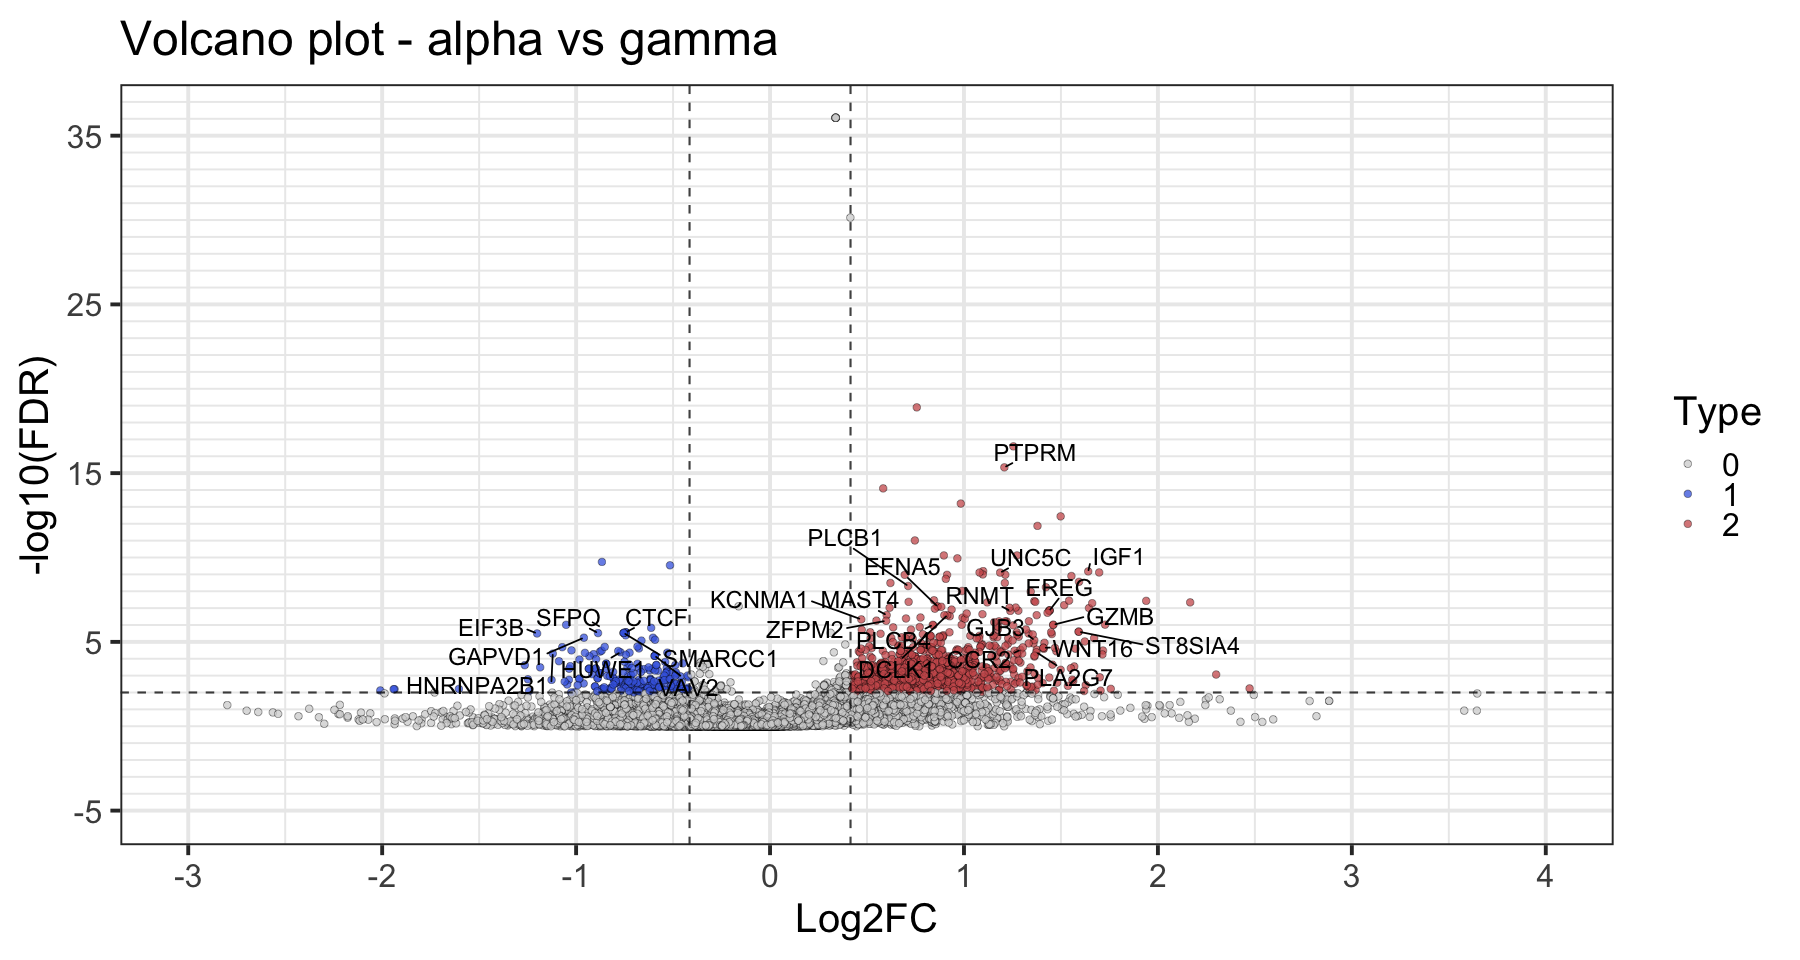

In [61]:
options(repr.plot.width=15, repr.plot.height=8)

p <- ggplot(markerList, aes(x = Log2FC, y = -log10(FDR))) +
  geom_point(aes(fill = signif), shape = 21,color = "black" , size = 2, stroke = 0.2,, alpha = 0.75)+
  scale_fill_manual(name = "Type",
                    values = c("0" = "lightgrey",
                               "1" = "royalblue",
                               "2" = "indianred"))+
  geom_vline(aes(xintercept = log2(4/3)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  geom_vline(aes(xintercept = log2(0.75)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  geom_hline(aes(yintercept = -log10(0.01)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  scale_x_continuous(breaks = seq(-3,4,1), minor_breaks = seq(-3,4,0.5))+
  scale_y_continuous(breaks = seq(-5,40,10), minor_breaks = seq(-5,40,1))+
  coord_cartesian(xlim = c(-3,4), ylim = c(-5,36))+
  theme_bw(base_size = 24) +
  geom_text_repel(
    data = label_genes,
    aes(label = name),
    colour = "black",
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0
  ) +
  labs(title = "Volcano plot - alpha vs gamma")
p

### Venn diagram

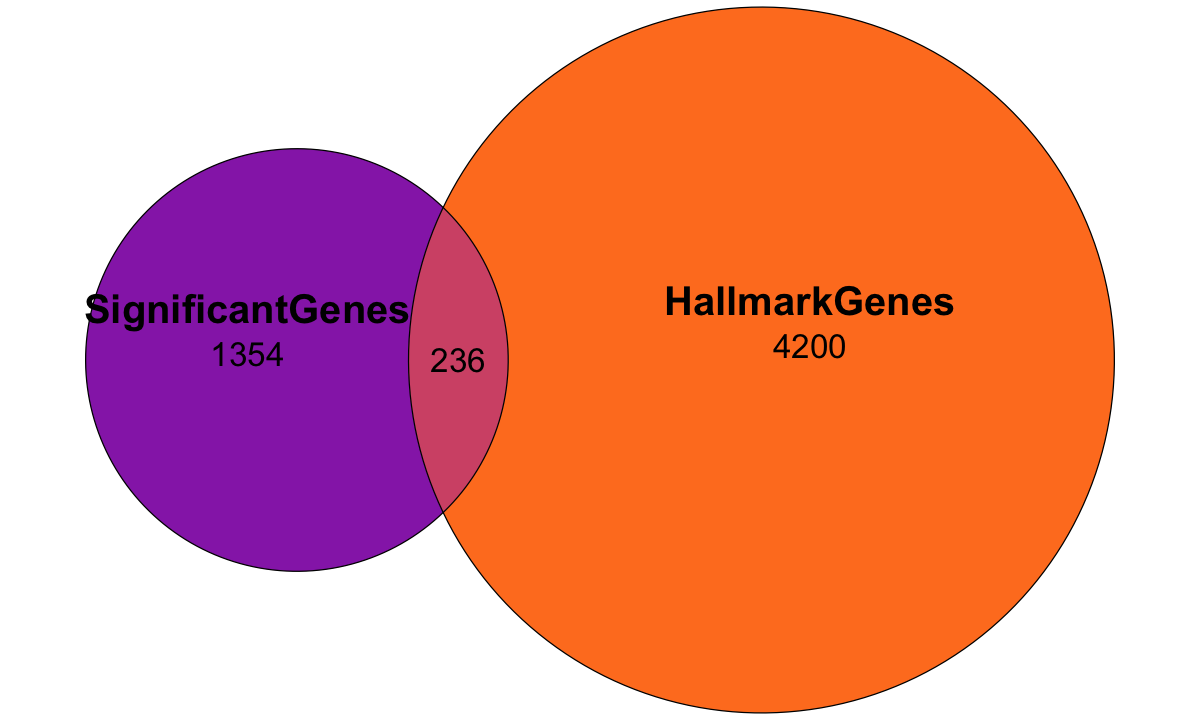

In [62]:
e <- euler(c("SignificantGenes" = length(unique(markerList[markerList$signif != 0,]$name)),
             "HallmarkGenes" = 4200,
             "SignificantGenes&HallmarkGenes" = length(unique(markerList[markerList$signif != 0 & markerList$Pathway != "Other",]$name))))
options(repr.plot.width=10, repr.plot.height=6)

plot(e, fills = c("#9731b6ff","#ff7f25ff"), fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

### Barplot of proportion of genes per pathway that are differentially accessible

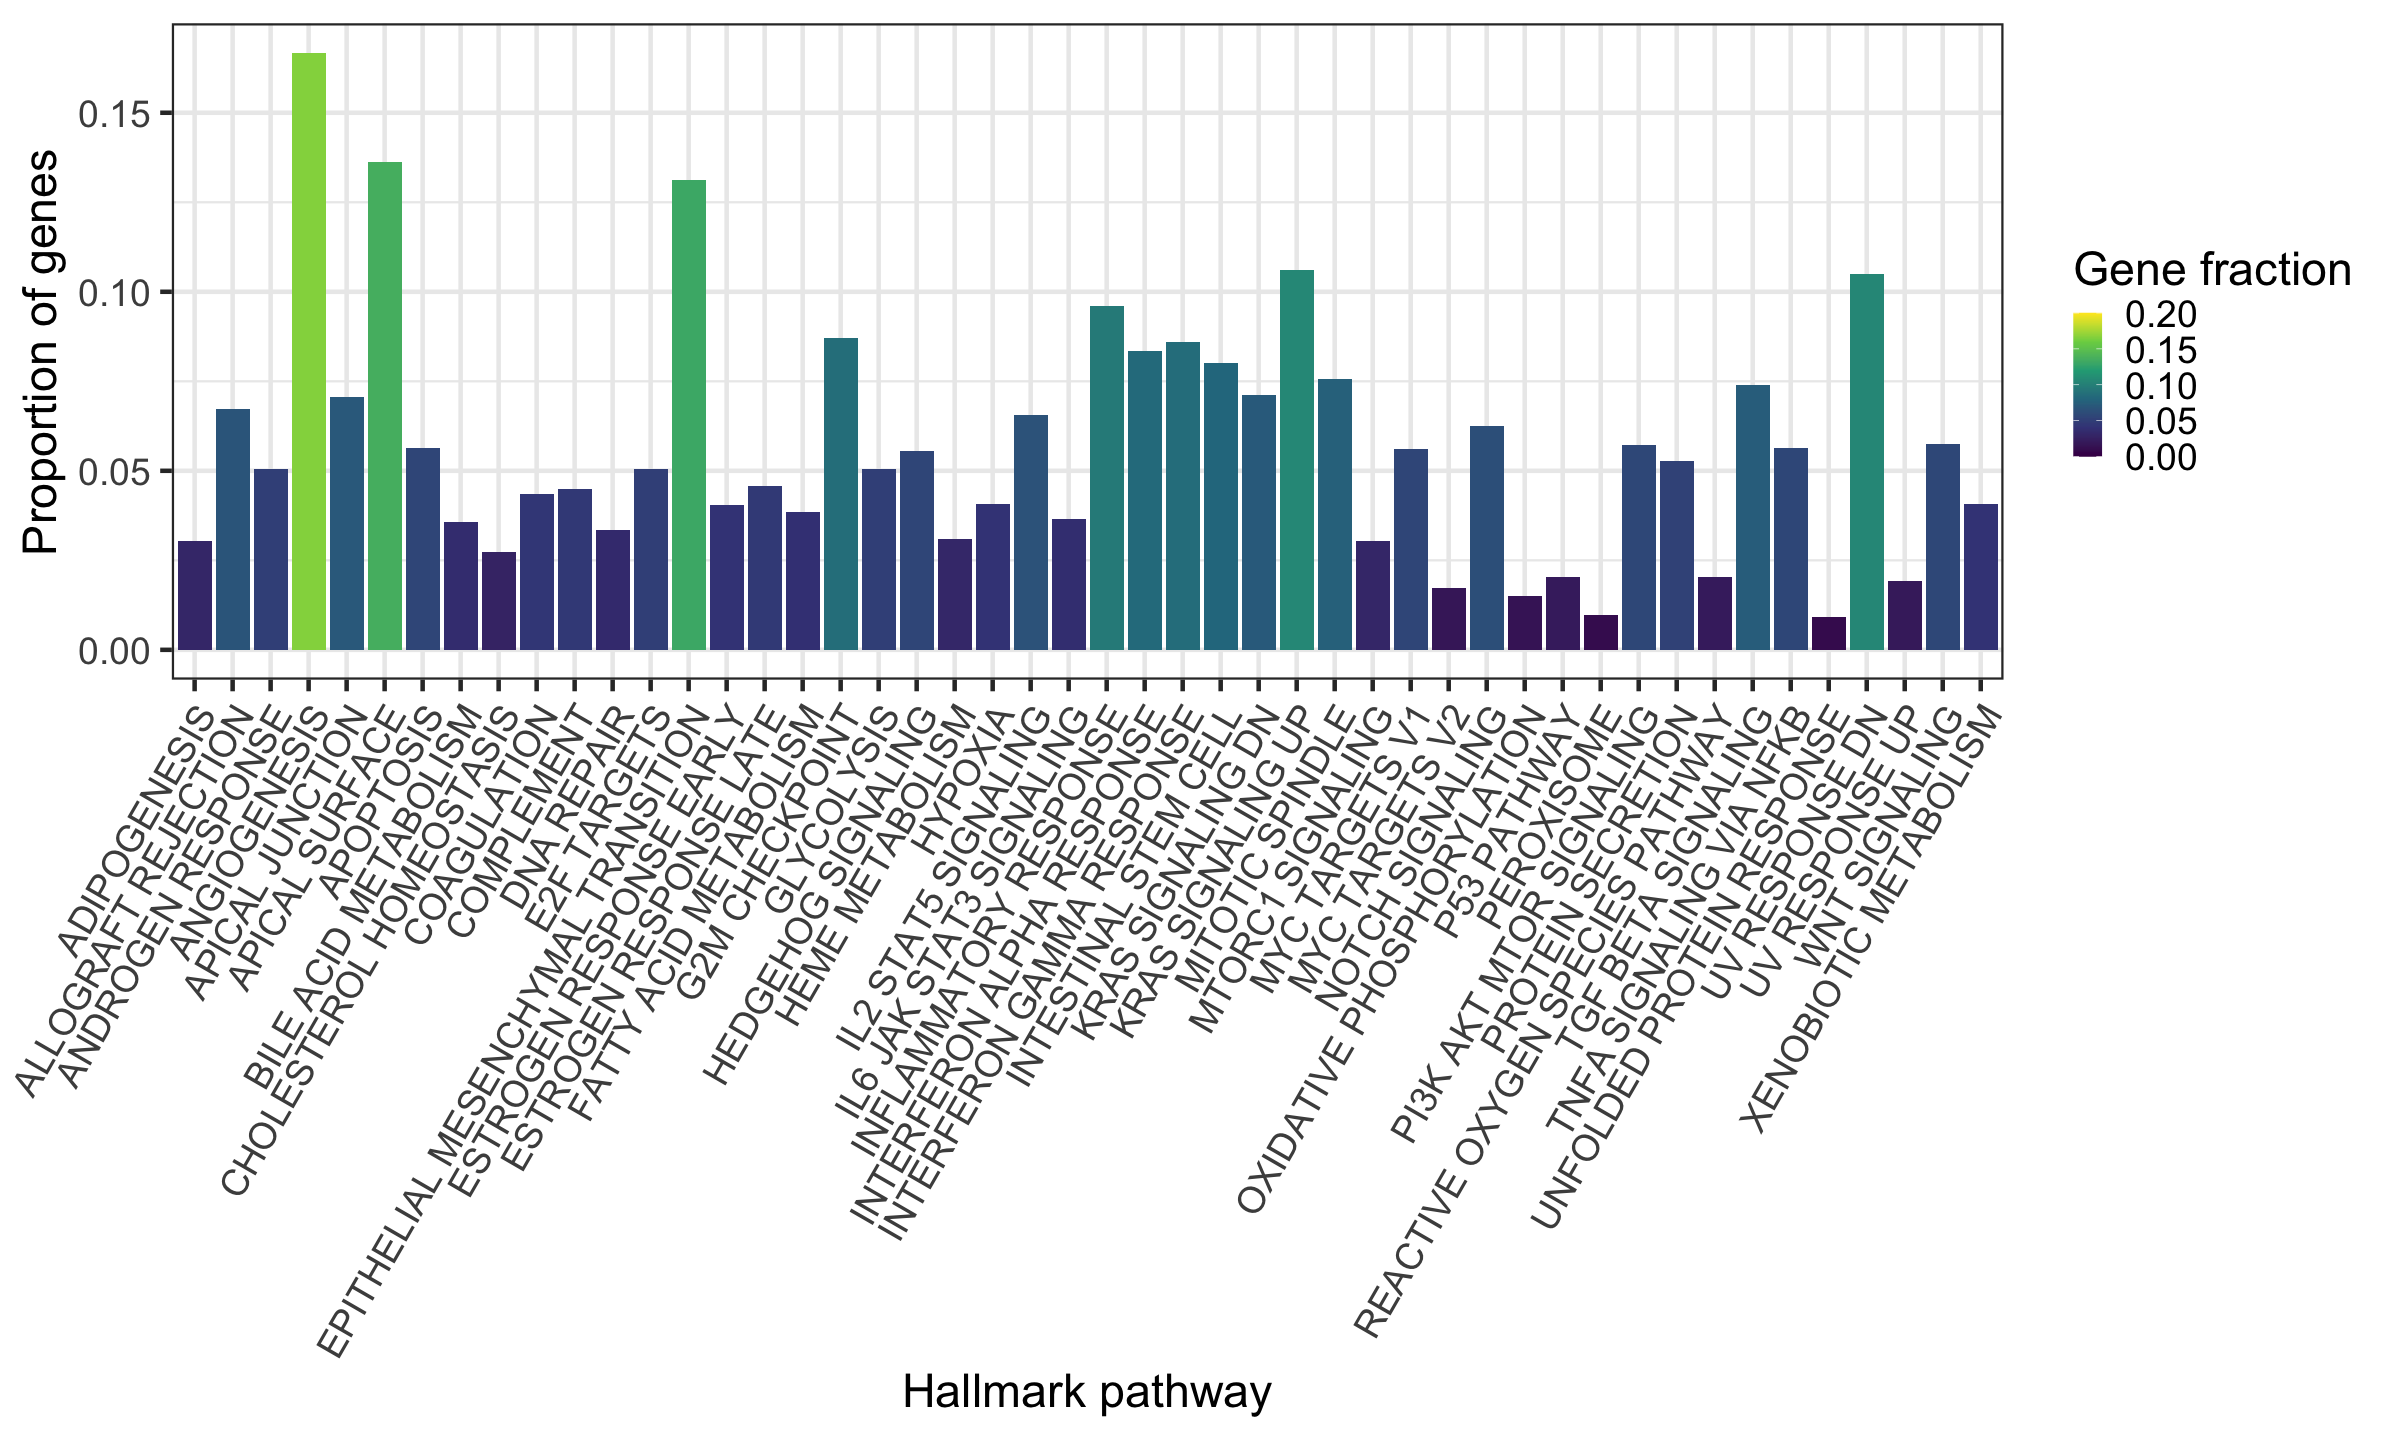

In [64]:
markerList$Pathway <- gsub("HALLMARK_","",markerList$Pathway)
markerList$Pathway <- gsub("_", " ", markerList$Pathway)
sig_counts <- markerList %>%
  filter(Pathway != "Other", signif != 0) %>%
  count(Pathway, name = "n_sig")

names <- gsub("HALLMARK_","",names(pathways))
names <- gsub("_", " ", names)  
pathway_sizes <- data.frame("Pathway" =  names, "n_total" = lengths(pathways)) 

plot_df <- sig_counts %>%
  left_join(pathway_sizes, by = "Pathway") %>%
  mutate(freq = n_sig / n_total)

options(repr.plot.width=20, repr.plot.height=12)

p <- ggplot(plot_df, aes(x = Pathway, y = freq)) +
  geom_col(aes(fill = freq)) +
  scale_fill_viridis_c(name = "Gene fraction",
                       limits = c(0,0.2)) +
  ylab("Proportion of genes") +
  xlab("Hallmark pathway") +
  theme_bw(base_size = 28) +
  theme(axis.text.x = element_text(angle = 60, vjust = 1, hjust = 1))
p

## Differential gene accessibility analysis: alpha vs delta

In [67]:
markerTest <- getMarkerFeatures(
  ArchRProj = proj_fil, 
  useMatrix = "GeneScoreMatrix",
  groupBy = "EpigeneticClass",
  testMethod = "wilcoxon",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  useGroups = "δ",
  bgdGroups = "α"
)

markerList <- data.frame(getMarkers( markerTest , cutOff = "FDR <= 1 & (Log2FC >= 0 | Log2FC <= 0)")[["δ"]])

genes <- c()
for (p in names(pathways)){
  genes <- rbind(genes, cbind("name" = pathways[[p]][which(pathways[[p]] %in% markerList$name)],
                              "Pathway" = rep(p, length(pathways[[p]][which(pathways[[p]] %in% markerList$name)]))))
}

genes <- data.frame(genes)

markerList <- merge(markerList, genes, by = "name", all.x = TRUE)
colnames(markerList)[10] <- "Pathway"

markerList$Pathway <- ifelse(is.na( markerList$Pathway), "Other",  markerList$Pathway)


markerList <- markerList %>% mutate(signif = case_when( FDR < 0.01 &
                                                          Log2FC <= log2(0.75) ~ "1",
                                                        FDR < 0.01 &
                                                          Log2FC >= log2(4/3) ~ "2",
                                                        .default = "0"))

label_genes <- markerList %>% filter( signif %in% c("1","2")  & Pathway != "Other" & ((-log10(FDR) > 3 & Log2FC < 0)| 
                                                                                        ( -log10(FDR) > 4.5 & Log2FC > 0) |
                                                                                        Log2FC > 1.25 |
                                                                                        Log2FC < -0.75) ) %>%
  distinct(name, .keep_all = T)

write_csv(label_genes[,c("name","Pathway")], "../../Data/ATAC_Data/DifferentialGeneAccessibility/VolcanoPlot_AlphavDelta_TopGenes_PathwayInfo.csv")
write_csv(markerList, "../../Data/ATAC_Data/DifferentialGeneAccessibility/VolcanoPlot_AlphavDelta_AllGenes_PathwayInfo.csv")


ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-5a776a77bd06-Date-2026-02-23_Time-15-07-04.043481.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-02-23 15:07:05.233811 : Matching Known Biases, 0.004 mins elapsed.

2026-02-23 15:07:06.183752 : Computing Pairwise Tests (1 of 1), 0.02 mins elapsed.

Pairwise Test δ : Seqnames chr1

Pairwise Test δ : Seqnames chr10

Pairwise Test δ : Seqnames chr11

Pairwise Test δ : Seqnames chr12

Pairwise Test δ : Seqnames chr13

Pairwise Test δ : Seqnames chr14

Pairwise Test δ : Seqnames chr15

Pairwise Test δ : Seqnames chr16

Pairwise Test δ : Seqnames chr17

Pairwise Test δ : Seqnames chr18

Pairwise Test δ : Seqnames chr19

Pairwise Test δ : Seqnames chr2

Pairwise Test δ : Seqnames chr20

Pairwise Test δ : Seqnames chr21

Pairwise Test δ : Seqnames chr22

Pairwise Test δ : Seqnames chr3

Pairwise Test δ : Seqnames chr4

Pairwise Test δ : Seqnames chr5

Pairwise Test δ : Seqnames chr6


### Volcano plot

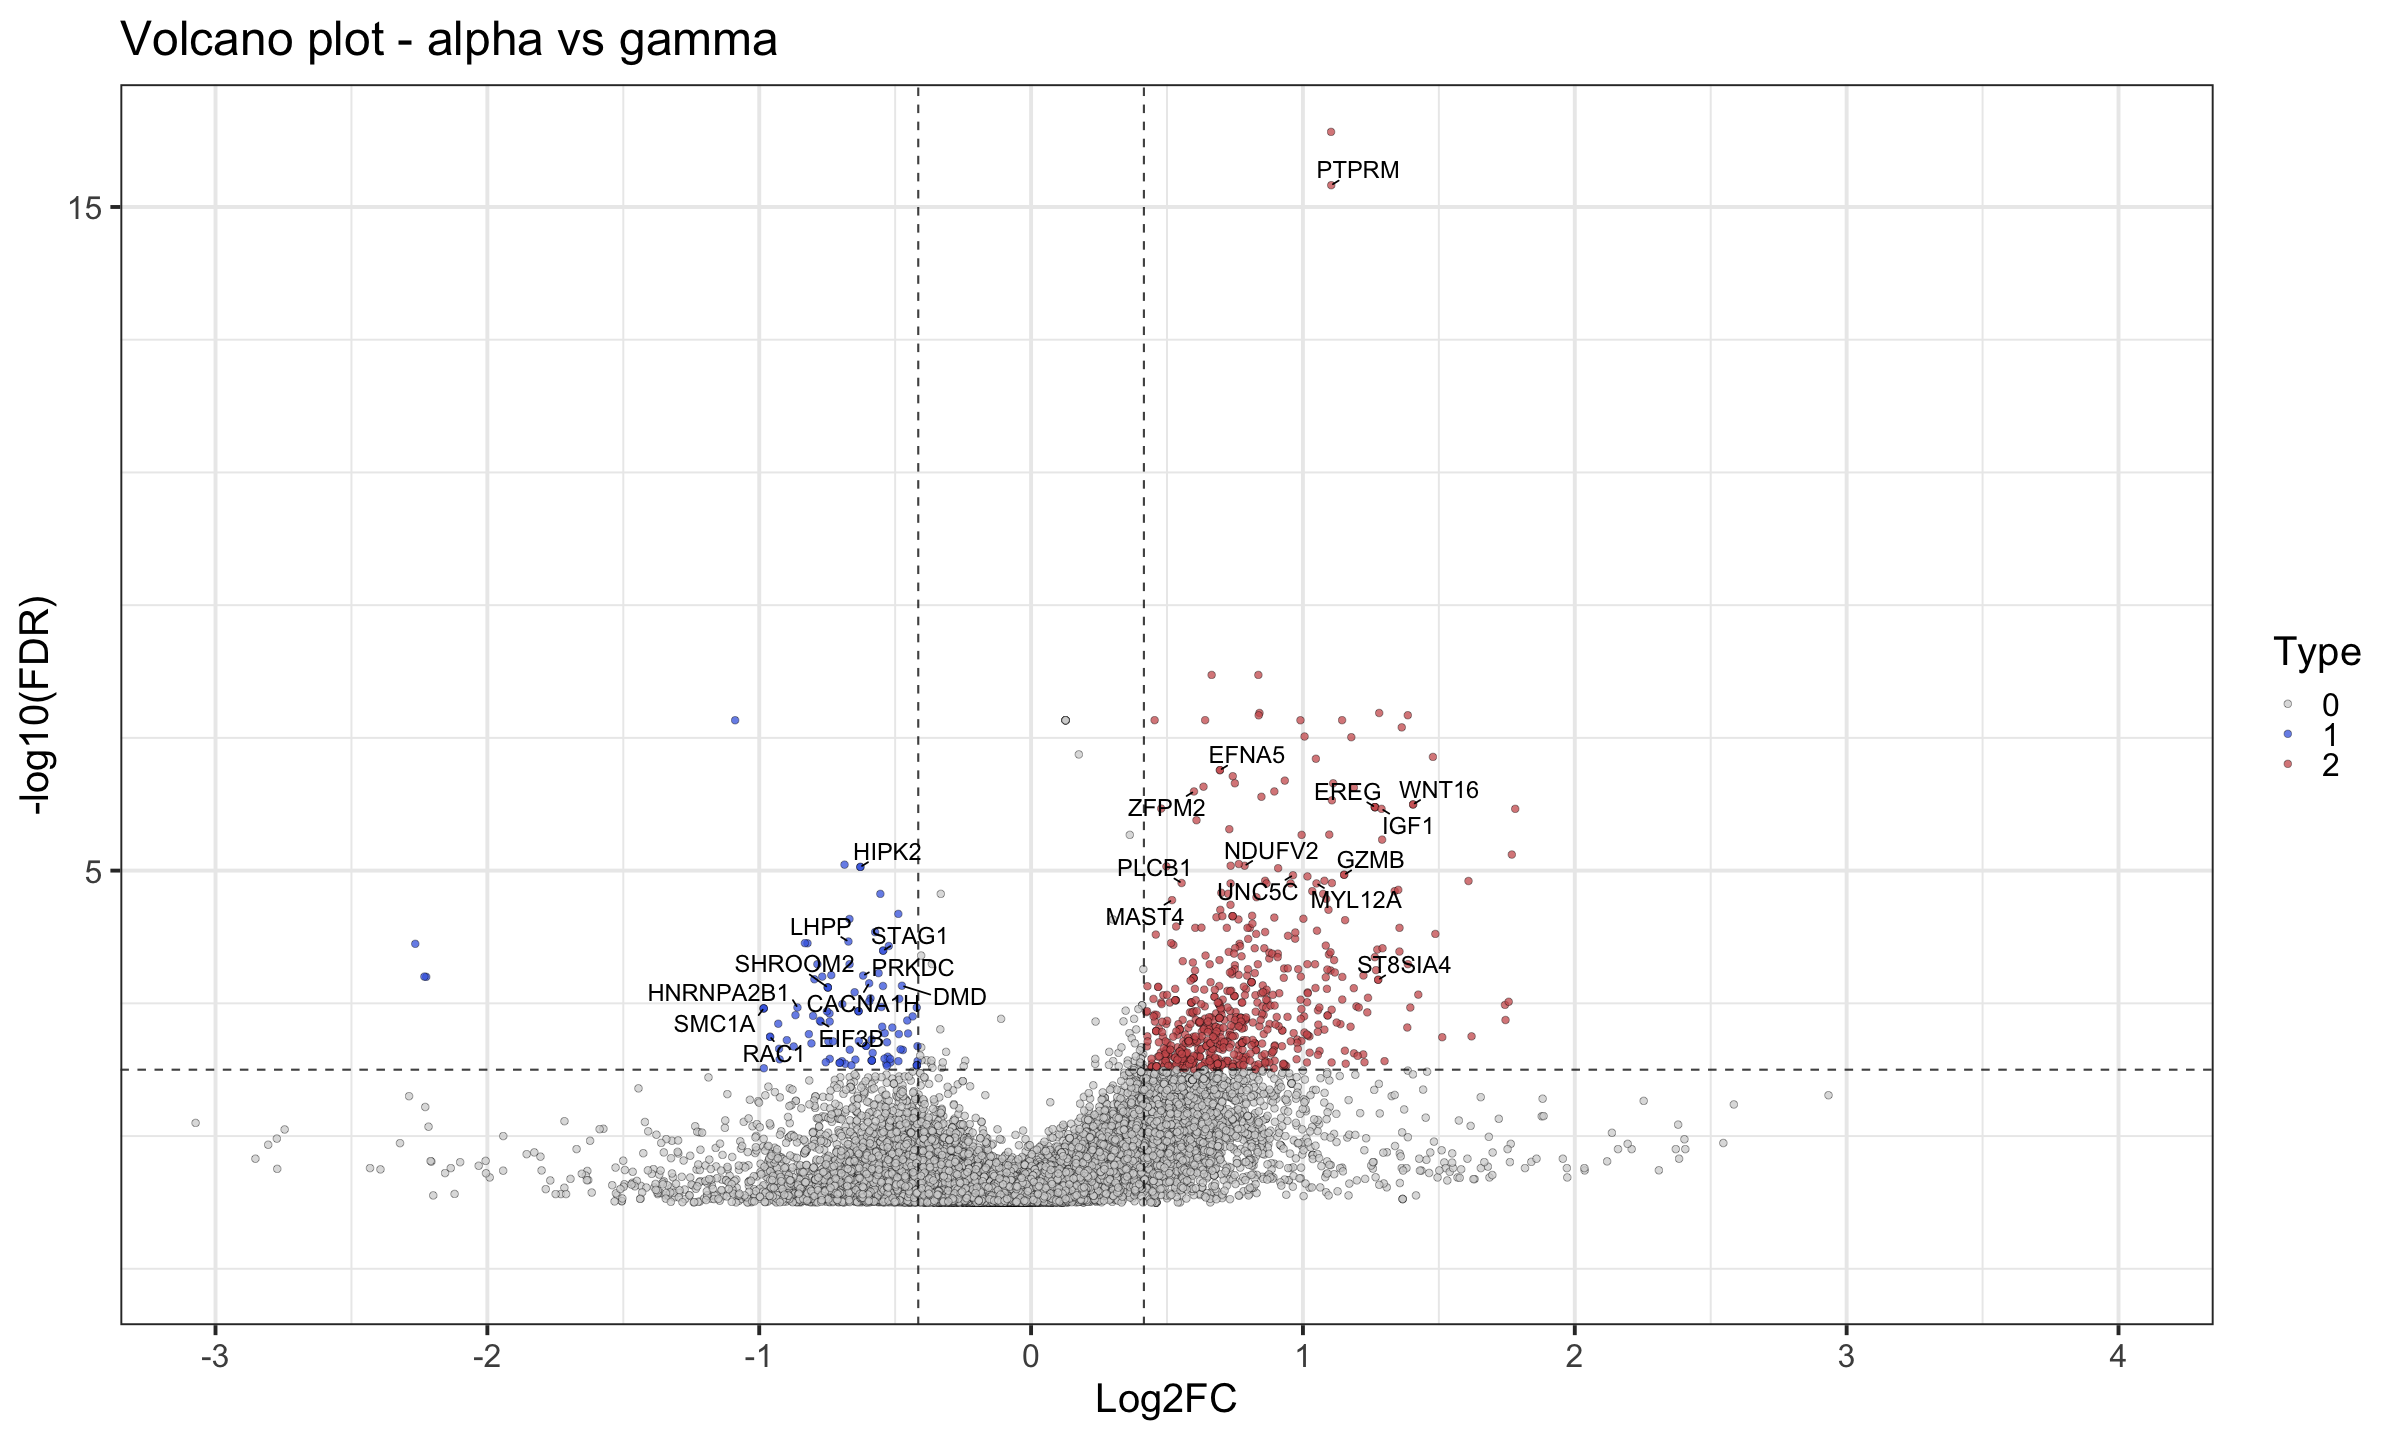

In [69]:
p <- ggplot(markerList, aes(x = Log2FC, y = -log10(FDR))) +
  geom_point(aes(fill = signif), shape = 21,color = "black" , size = 2, stroke = 0.2,, alpha = 0.75)+
  scale_fill_manual(name = "Type",
                    values = c("0" = "lightgrey",
                               "1" = "royalblue",
                               "2" = "indianred"))+
  geom_vline(aes(xintercept = log2(4/3)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  geom_vline(aes(xintercept = log2(0.75)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  geom_hline(aes(yintercept = -log10(0.01)), linetype = "dashed", colour = "black", linewidth = 0.6, alpha = 0.75)+
  scale_x_continuous(breaks = seq(-3,4,1), minor_breaks = seq(-3,4,0.5))+
  scale_y_continuous(breaks = seq(-5,40,10), minor_breaks = seq(-5,40,2))+
  coord_cartesian(xlim = c(-3,4), ylim = c(-1,16))+
  theme_bw(base_size = 24) +
  geom_text_repel(
    data = label_genes,
    aes(label = name),
    colour = "black",
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0
  ) +
  labs(title = "Volcano plot - alpha vs gamma")
p

### Venn diagram

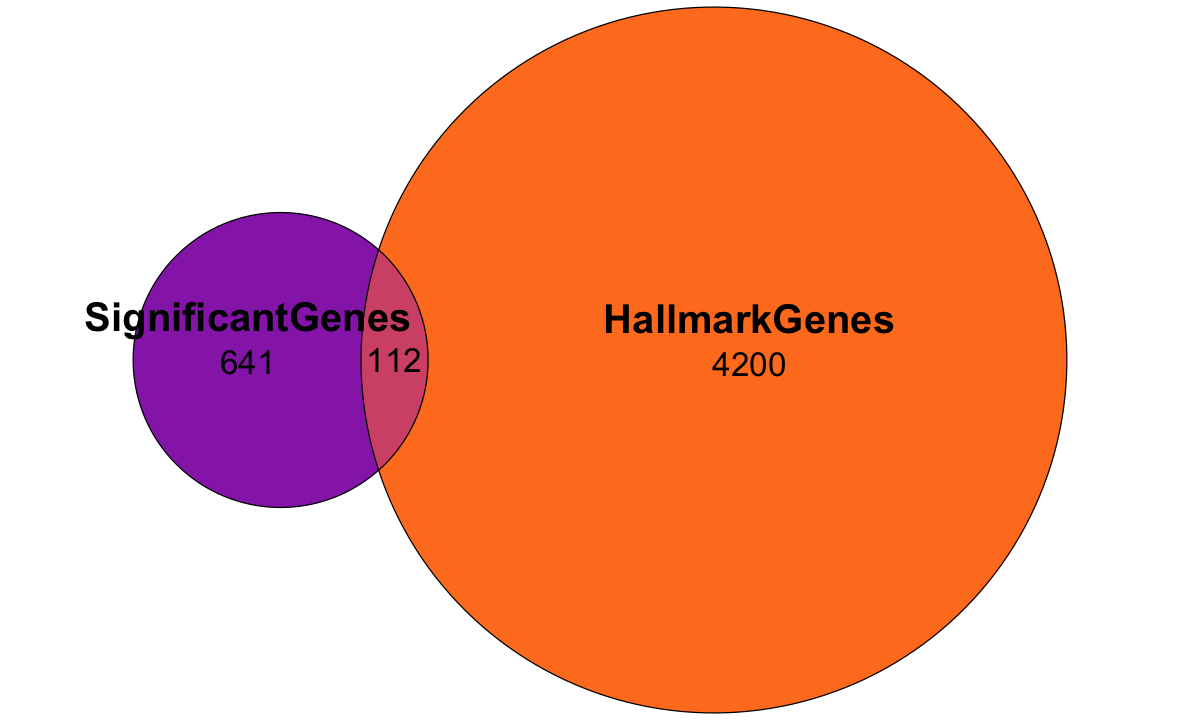

In [70]:
e <- euler(c("SignificantGenes" = length(unique(markerList[markerList$signif != 0,]$name)),
             "HallmarkGenes" = 4200,
             "SignificantGenes&HallmarkGenes" = length(unique(markerList[markerList$signif != 0 & markerList$Pathway != "Other",]$name))))

options(repr.plot.width=10, repr.plot.height=6)

plot(e, fills = c("#9731b6ff","#ff7f25ff"), fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

### Barplot of proportion of genes per pathway that are differentially accessible

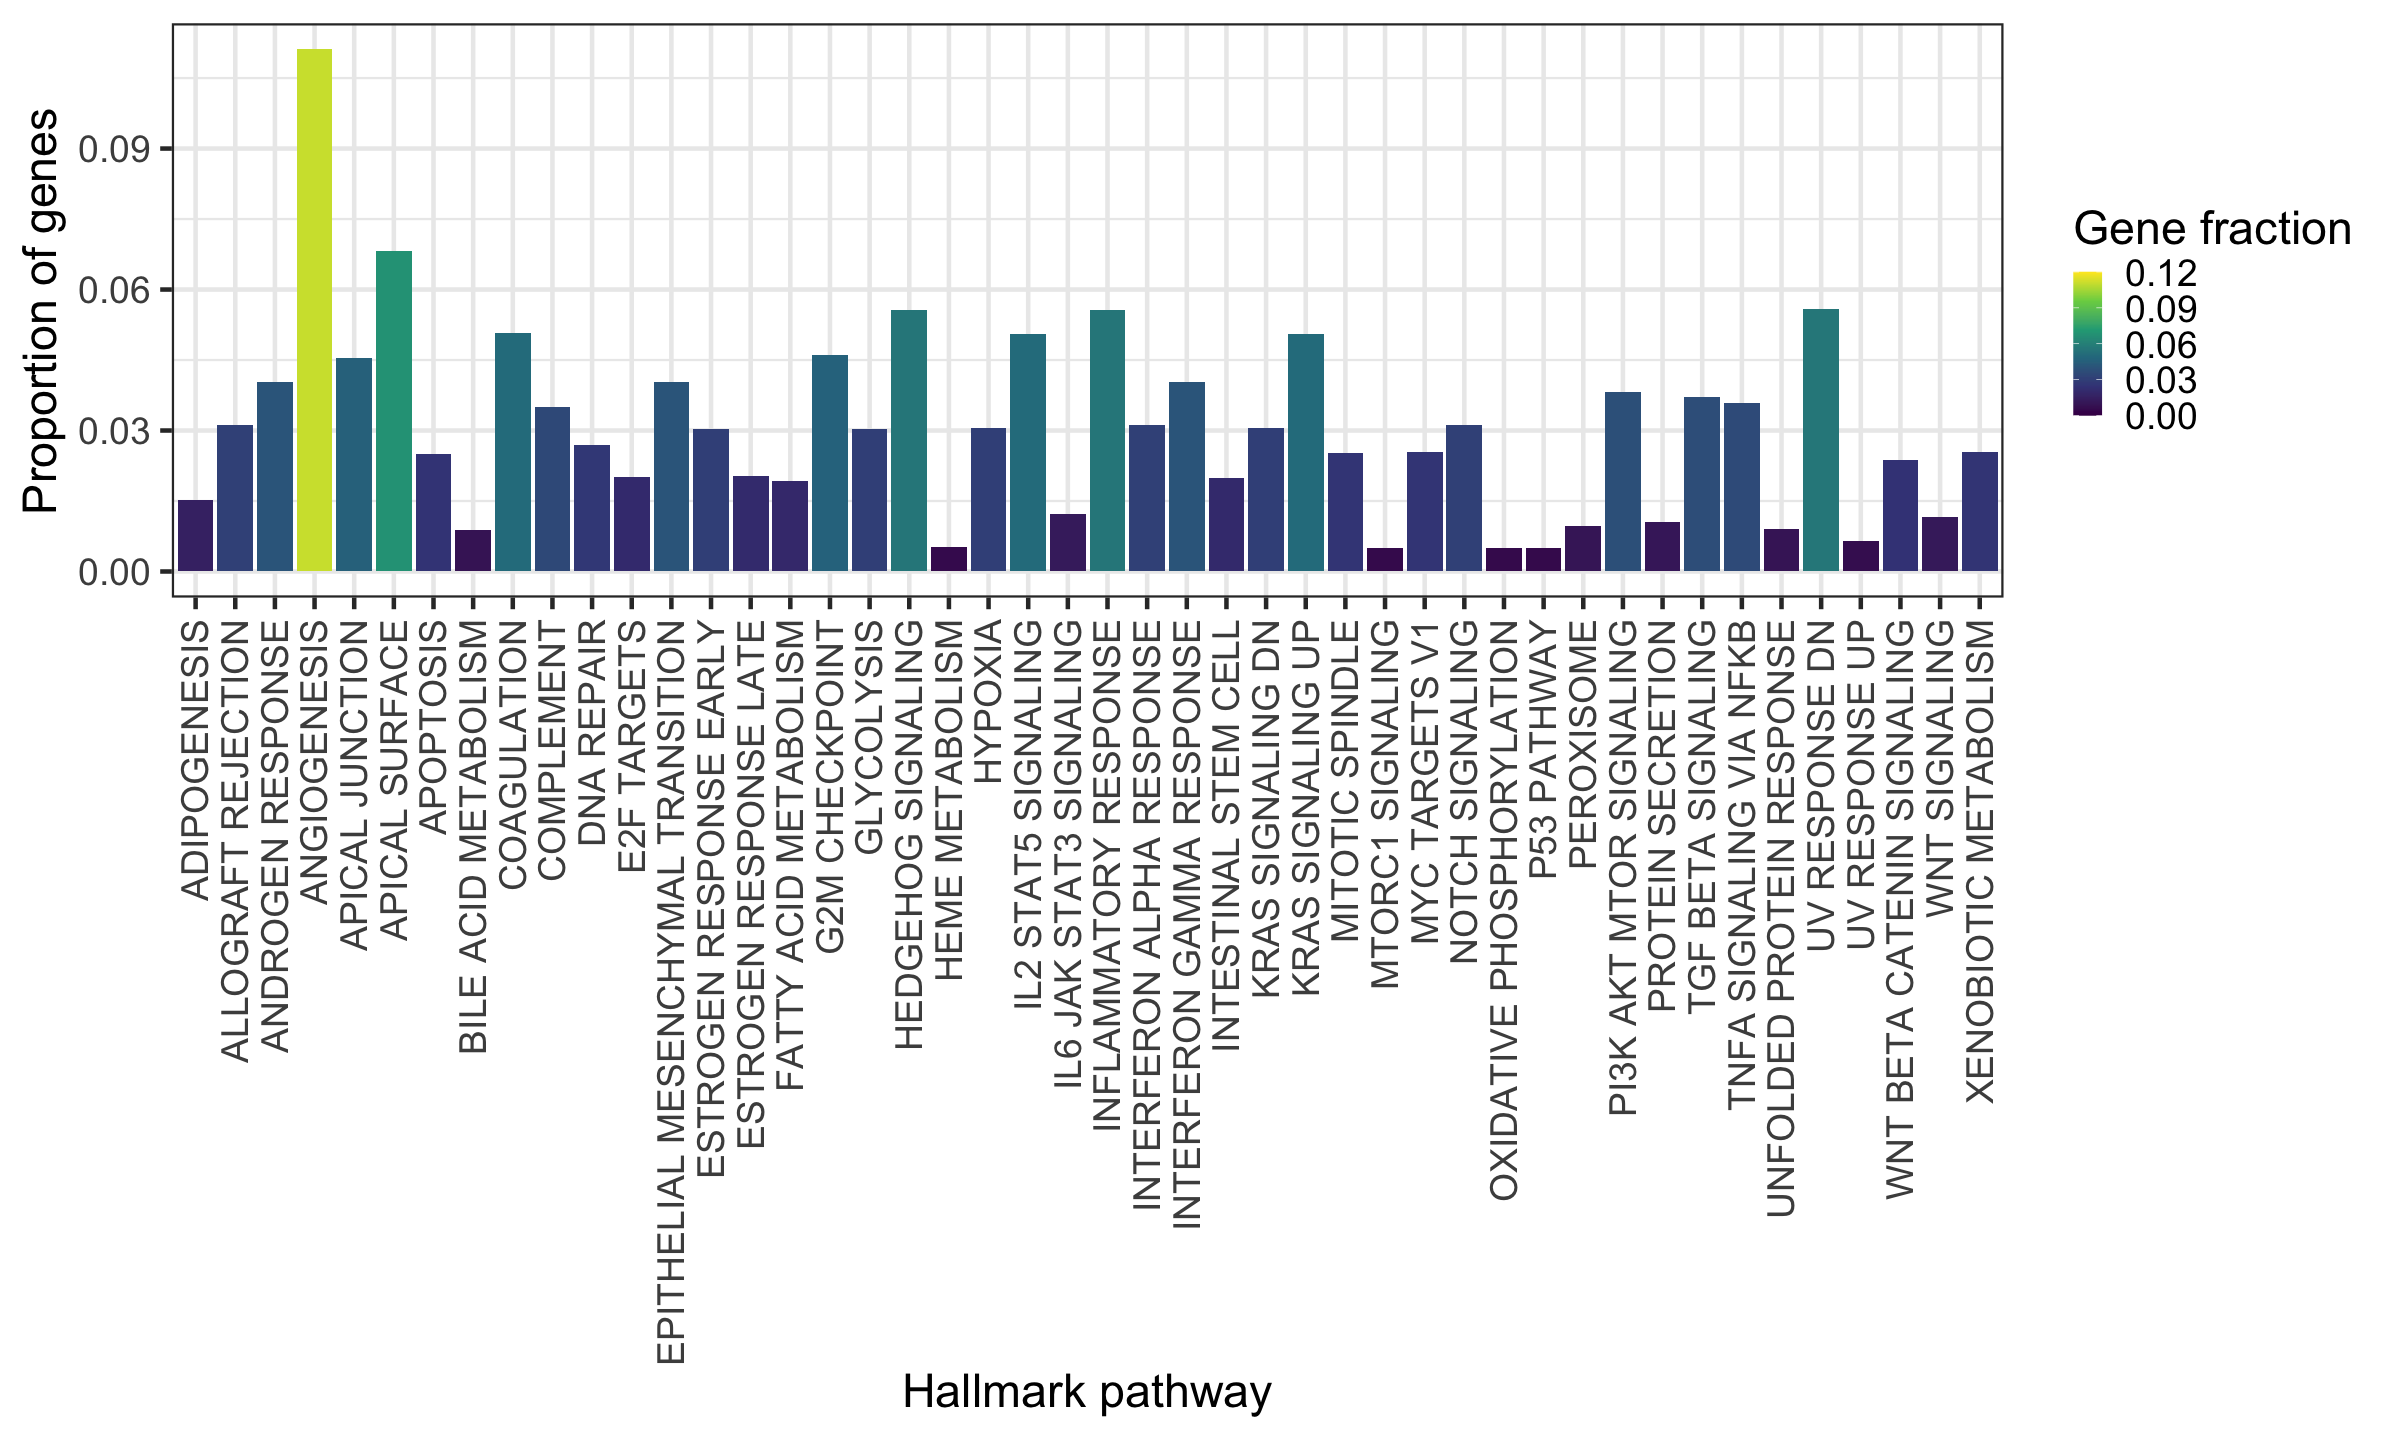

In [71]:
markerList$Pathway <- gsub("HALLMARK_","",markerList$Pathway)
markerList$Pathway <- gsub("_", " ", markerList$Pathway)

sig_counts <- markerList %>%
  filter(Pathway != "Other", signif != 0) %>%
  count(Pathway, name = "n_sig")

names <- gsub("HALLMARK_","",names(pathways))
names <- gsub("_", " ", names)  
pathway_sizes <- data.frame("Pathway" =  names, "n_total" = lengths(pathways)) 

plot_df <- sig_counts %>%
  left_join(pathway_sizes, by = "Pathway") %>%
  mutate(freq = n_sig / n_total)

options(repr.plot.width=20, repr.plot.height=12)

p <- ggplot(plot_df, aes(x = Pathway, y = freq)) +
  geom_col(aes(fill = freq)) +
  scale_fill_viridis_c(name = "Gene fraction",
                       limits = c(0,0.12)) +
  ylab("Proportion of genes") +
  xlab("Hallmark pathway") +
  theme_bw(base_size = 28) +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))
p